<center>
<h4>The Harmful Algal Blooms: A Multiple Linear Regression Model of Chlorophyll-a Concentrations in Bolinao, Pangasinan </h4>
<b><u>Romand Lansangan</b></u>
<p>2025/06/03</p>
</center>

---

## Introduction
The Harmful Algal Blooms (HABs known as red tides) has become a greatest concern at Bolinao, Pangasinan back in 2022. HABs is a phenomenon where the algal state of the algae produces such toxic chemicals, release to its environment, and oxygen concentration over water plummets, hence many aquatic organisms suffer, disrupting the entire food chain. Consequently, HABs destroy human livelihoods and health safety. Consumption of meats with HABs exposure content might lead to skin irritation, respiratory problems, and some extreme conditions of paralytic poisoning. Overall, Bolinao, Pangasinan’s Marine Ecosystems offers less quantity and quality of fishes caught due to HABs event back in 2022.

## Objective

The primary purpose of this study is to developing linear regression models (maximizing its Adj RSq) and determine which predictor could contribute to increase/decrease of the chlorophyll-a levels that triggers the Harmful Algal Blooms (HABs) in Bolinao, Pangasinan provided the dataset “Harmful Algae Blooms in Bolinao” (from HABhub, 2022) and analyzing its 2022 biological and environmental observations given the following features:

- `station_name`: (Categorical) the station who’s responsible for detecting any biological and environmental observations happening within their assigned embayment
- `embayment`: (Categorical) the name of the area where coastal water body is located
- `longitude`: (Continuous) the state of east-west geographic coordinate
- `latitude`: (Continuous) the state of north-south geographic coordinate
- `sample_date`: (Date in YYYY-MM-DD format) the calendar date on which the environmental and biological observations were recorded
- `dissolved_oxygen`: (Continuous) the concentration of oxygen gas dissolved in water, typically measured in milligrams per liter (mg/L)
- `ph`: (Continuous) the state on how acidic or basic the water is, that is usually on a scale 0 – 14
- `water_temp`: (Continuous) the temperature of the water in degrees Celsius.
- `time`: (Time in HH:01:00 format) the hour of the day when the sample or observation was taken

The dataset was obtained from the official HABHub website developed by “the Marine Science institute under the University of Philippine Diliman (UP-MSI) and that dataset is supported by the Department of Science and Technology’s Philippine Council for Agriculture, Aquatic and Natural Resources Research and Development (DOST-PCAARRD)” (as declared in HABHub, 2022). Thus the website itself provides some open public datasets that tackles about the Harmful Algal Blooms (HABs) advisories, hence, we obtain the file “Harmful Algae Blooms in Bolinao (from HABhub) - Sheet1.csv”



In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_theme()
plt.rcParams['figure.facecolor'] = 'lightgrey'
plt.rcParams['axes.facecolor'] = 'lightgrey'
plt.rcParams['font.family'] = 'serif'

In [43]:
df = pd.read_csv("Harmful Algae Blooms in Bolinao (from HABhub) - Sheet1.csv")
print(df.shape)
print(df.info())
df.head()

(1929, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1929 entries, 0 to 1928
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   station_name      1929 non-null   object 
 1   embayment         1929 non-null   object 
 2   longitude         1929 non-null   float64
 3   latitude          1929 non-null   float64
 4   sample_date       1929 non-null   object 
 5   dissolved oxygen  1929 non-null   float64
 6   ph                1929 non-null   float64
 7   water temp        1929 non-null   float64
 8   time              1929 non-null   object 
 9   chlorophyll-a     1929 non-null   float64
dtypes: float64(6), object(4)
memory usage: 150.8+ KB
None


,station_name,embayment,longitude,latitude,sample_date,dissolved oxygen,ph,water temp,time,chlorophyll-a
0,CCMS_BML,Bolinao,119.9252,16.38712,2022-08-11,-0.5200,7.5755,28.8045,0:01:00,2.6136
1,CCMS_BML,Bolinao,119.9252,16.38712,2022-08-11,-1.0384,7.5566,28.7676,1:01:00,2.4442
2,CCMS_BML,Bolinao,119.9252,16.38712,2022-08-11,-0.9472,7.5881,28.7926,2:01:00,2.6257
3,CCMS_BML,Bolinao,119.9252,16.38712,2022-08-11,-1.1008,7.5566,28.7575,3:01:00,2.2264
4,CCMS_BML,Bolinao,119.9252,16.38712,2022-08-11,-0.9424,7.6007,28.8213,4:01:00,2.4079


## Split
Let us split the data first to prevent any leakage

In [44]:
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)

In [45]:
df_train.nunique()

station_name           1
embayment              1
longitude              1
latitude               1
sample_date           92
dissolved oxygen     868
ph                   244
water temp          1480
time                  24
chlorophyll-a        689
dtype: int64

In [46]:
cont_vars = df_train.nunique() != 1
filtered_df = df_train[df_train.columns[cont_vars]]
filtered_df = filtered_df.rename(columns={"chlorophyll-a": "chl", 
                                         "dissolved oxygen": "dissolved_oxygen",
                                         "water temp": "water_temp"})
filtered_df

,sample_date,dissolved_oxygen,ph,water_temp,time,chl
1352,2022-10-12,-2.6848,6.9140,30.6774,6:01:00,4.6948
141,2022-08-17,0.3344,7.5692,29.8578,2:01:00,3.4848
2,2022-08-11,-0.9472,7.5881,28.7926,2:01:00,2.6257
1190,2022-10-01,-0.7552,6.8762,30.2540,10:01:00,2.9645
1803,2023-10-02,1.1163,-0.2700,32.4355,15:01:00,1.6214
...,...,...,...,...,...,...
1130,2022-09-28,-1.3408,6.9896,29.6580,22:01:00,2.9282
1294,2022-10-07,0.2960,6.8825,31.8933,19:01:00,7.3689
860,2022-09-17,-1.2544,6.8069,30.6729,13:01:00,4.5980
1459,2022-10-18,-2.6992,6.7754,29.7998,0:01:00,1.6335


<Axes: title={'center': 'CHL Distribution with TIME'}, xlabel='sample_date', ylabel='CHL'>

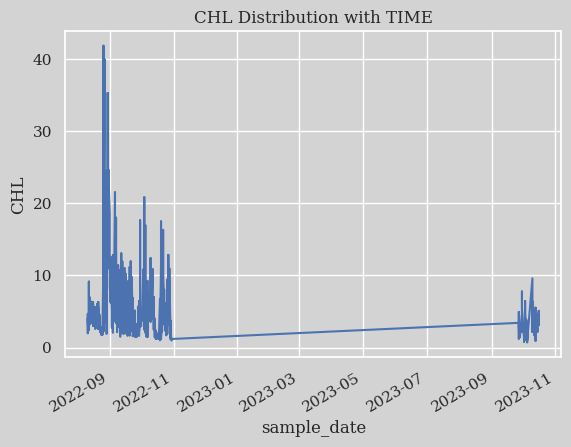

In [47]:
chl_time_series = pd.Series(filtered_df['chl'].values, index=pd.to_datetime(filtered_df["sample_date"])).sort_index()
chl_time_series.plot(title="CHL Distribution with TIME", ylabel="CHL")

<Axes: title={'center': 'CHL Distribution with TIME'}, xlabel='sample_date', ylabel='CHL'>

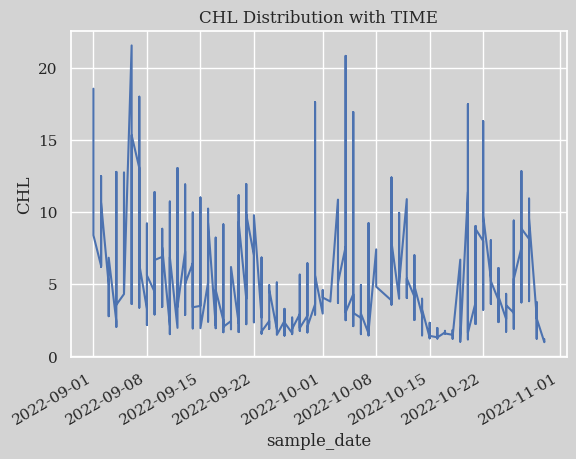

In [48]:
chl_time_series.loc["2022-09":"2022-11"].plot(title="CHL Distribution with TIME", ylabel="CHL")

In [49]:
from statsmodels.tsa.stattools import adfuller 
result = adfuller(chl_time_series.loc["2022-09":"2022-11"], regression='ct')
confi = 0.05

if result[1] < confi:
    print("Time series is stationary with P-Value =", result[1])
else:
    print("Time series is non-stationary with P-Value =", result[1])

Time series is stationary with P-Value = 0.020261732853314625


In [50]:
result = adfuller(chl_time_series.loc["2022-09":"2022-11"], regression="ct")
if result[1] < confi:
    print("Time series is stationary with P-Value =", result[1])
else:
    print("Time series is non-stationary with P-Value =", result[1])

Time series is stationary with P-Value = 0.020261732853314625


According to Augmented Dickey-Fuller (ADF) test, the time series is stationary, this means that mean and variance of `chl` are constant through time. Since the ADF test confirms stationarity, there's no significant long term trend or seasonal pattern in `chl` over time.  

In [51]:
filtered_df['sample_date'] = pd.to_datetime(filtered_df["sample_date"])

filtered_df['time_hour'] = pd.to_datetime(filtered_df['time'], format="%H:%M:%S").dt.hour
filtered_df.drop(columns=["time"], inplace=True)

start = "2022-09-01"
end = "2022-11-01"
mask = (filtered_df['sample_date'] > start) & (filtered_df['sample_date'] <= end)
filtered_df = filtered_df[mask].copy()
filtered_df['sample_date'] = filtered_df['sample_date'].dt.day_of_year

filtered_df.head()

,sample_date,dissolved_oxygen,ph,water_temp,chl,time_hour
1352,285,-2.6848,6.9140,30.6774,4.6948,6
1190,274,-0.7552,6.8762,30.2540,2.9645,10
1116,271,-0.8416,7.0274,28.9762,1.7908,8
584,248,-1.4032,7.5692,27.9160,7.8045,22
607,249,-1.2160,7.2227,29.1612,18.1379,21


---

## Baseline Model

In [52]:
from statsmodels.formula.api import ols

formula = "chl ~ " + " + ".join([col for col in filtered_df.columns  if col != "chl"])
lmlm = ols(formula, data=filtered_df)
results_baseline = lmlm.fit()
results_baseline.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    chl   R-squared:                       0.240
Model:                            OLS   Adj. R-squared:                  0.237
Method:                 Least Squares   F-statistic:                     64.01
Date:                Tue, 03 Jun 2025   Prob (F-statistic):           4.25e-58
Time:                        14:05:27   Log-Likelihood:                -2517.6
No. Observations:                1017   AIC:                             5047.
Df Residuals:                    1011   BIC:                             5077.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
====================================================================================
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          -74.5517      9.230     -8.077      0.000     -92.664     -56.439
sample_date         -0.0059      0.007     -0.818      0.413      -0.020       0.008
dissolved_oxygen     0.1861      0.072      2.583      0.010       0.045       0.328
ph                   5.7129      0.751      7.607      0.000       4.239       7.187
water_temp           1.3089      0.127     10.331      0.000       1.060       1.557
time_hour            0.1462      0.014     10.799      0.000       0.120       0.173
==============================================================================
Omnibus:                      353.836   Durbin-Watson:                   1.914
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1283.434
Skew:                           1.663   Prob(JB):                    2.02e-279
Kurtosis:                       7.385   Cond. No.                     2.82e+04
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.82e+04. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

All are significant except `sample_date`. Adj R-Sq is low with 0.246 so we got a lot of transformation to do to  Let's look at the distributions to see if we can leverage any transformation. 

---
## EDA

#### Missing Values

In [53]:
filtered_df.isna().sum()

sample_date         0
dissolved_oxygen    0
ph                  0
water_temp          0
chl                 0
time_hour           0
dtype: int64

#### Distribution

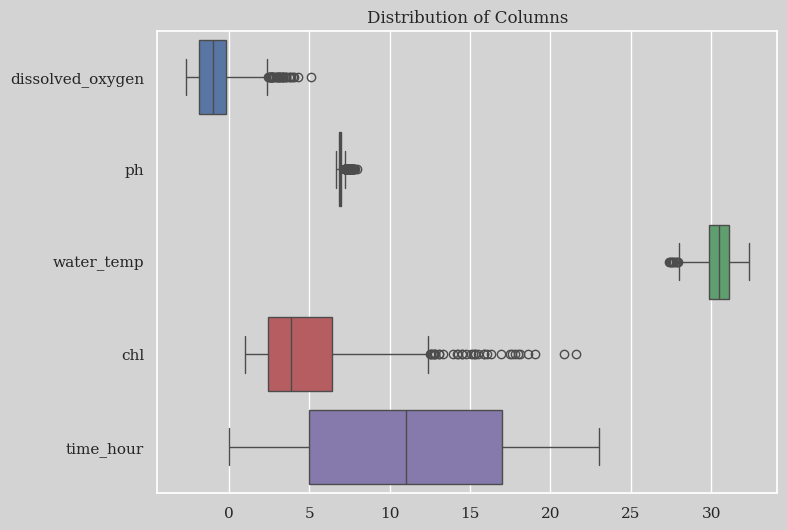

In [54]:
plt.figure(figsize=(8, 6))

sns.boxplot(filtered_df.drop(columns='sample_date'), orient="h")
plt.title("Distribution of Columns");

Lots of outliers in all of columns with exceptions of time related columns.

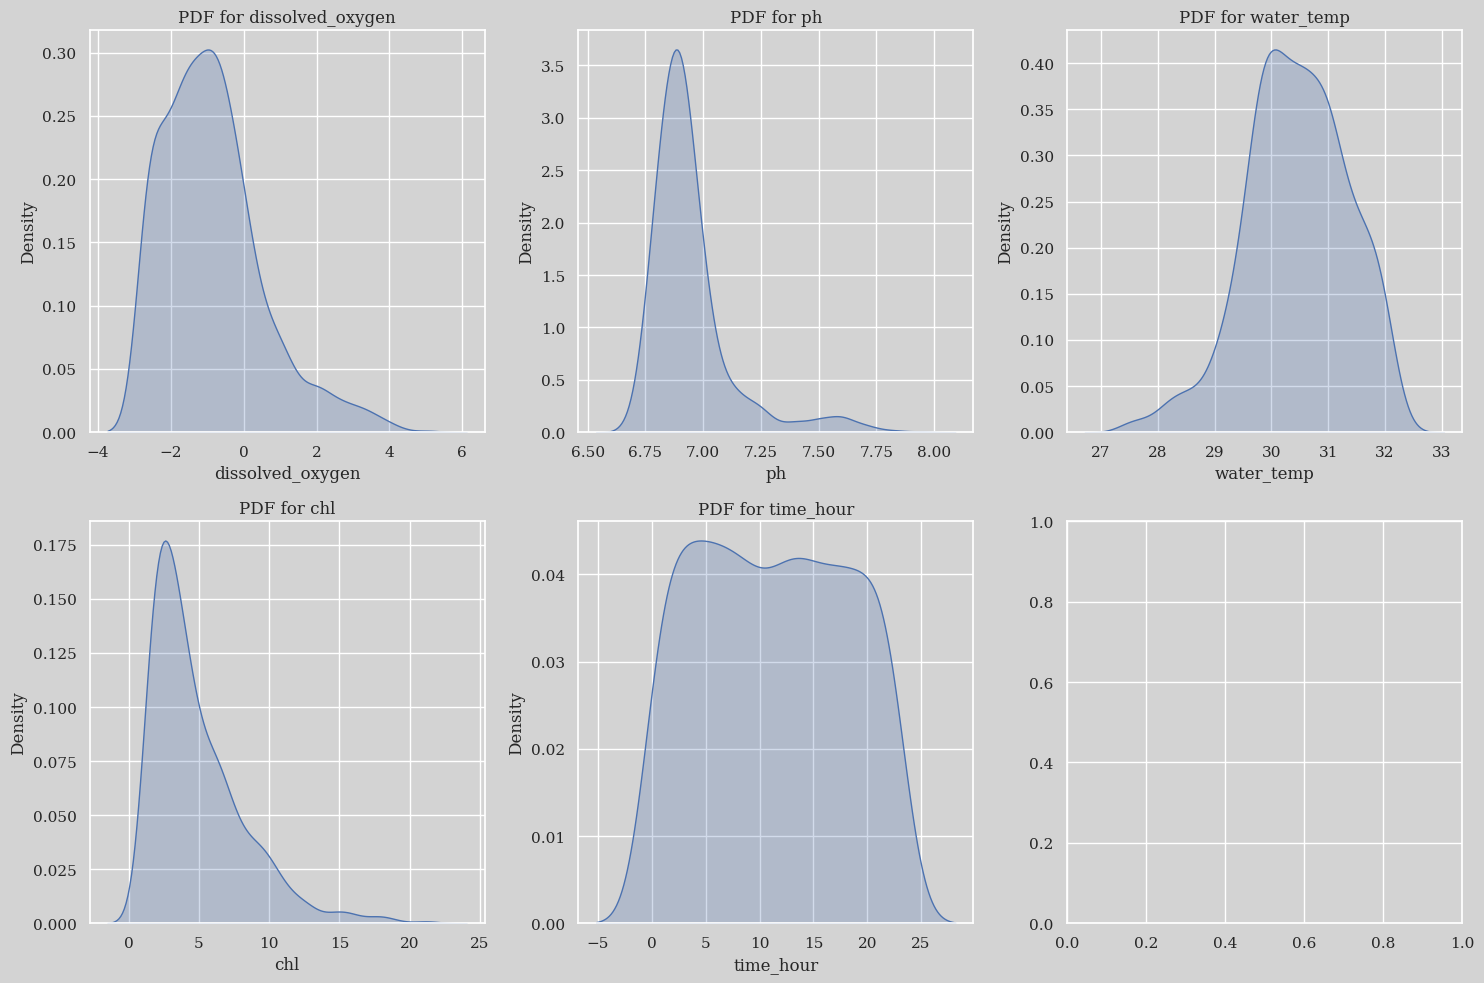

In [55]:
cols = filtered_df.drop(columns=['sample_date']).columns.to_list()
rows = int(np.ceil(len(cols) / 3))

fig, ax = plt.subplots(ncols=3, nrows=rows, figsize=(15,5*rows))
axes = ax.flatten()


for ind,col in enumerate(cols):
    sns.kdeplot(filtered_df[col], fill=True, ax=axes[ind])
    axes[ind].set_title(f"PDF for {col}")

plt.tight_layout()

Well it appears that all of our columns are skewed! With the exceptions of `water_temp`, `time_hour`, and `day_week`.

The shape of the distribution isn't usually an issue in a linear regression model but given that we also got significant amount of outliers for each of those skewed data, a transformation is in order. With transformation, we can reduce the outliers and normalize the data which is ultimately beneficial for our linear model.

Let's look at the domain for each column before proceeding.

In [56]:
filtered_df.agg(['min','max'])

,sample_date,dissolved_oxygen,ph,water_temp,chl,time_hour
min,245,-2.6992,6.6746,27.3922,0.9801,0
max,303,5.0816,7.9535,32.3600,21.5622,23


In [57]:
filtered_df["ph"].describe()

count    1017.000000
mean        6.944658
std         0.182797
min         6.674600
25%         6.838400
50%         6.901400
75%         6.983300
max         7.953500
Name: ph, dtype: float64

### Applying Transformation to Dependent Variable

The primary rationale behind transforming the Dependent Variable, `chl`, was to address the outliers. As was shown in the boxplot earlier, numerous outliers exist and this is problematic since it could significantly increase the bias in the model. The `chl` also does not have any restrictions when it comes to transformations (see domain/range/min-max table). 

#### Power Transformation: Yeo-Johnson
The modeler chose Yeo-Johnson as the most applicable transformation to the dependent variable to cap its outliers.  Yeo-Johnson is an extension of Box-Cox transformation and Log Transformation, other common transformations, but could handle zero or negative values.

#### Implications of Yeo-Johnson
Some of the implications of applying Yeo-Johnson to the dependent variable are as follows:
- Improve the distribution - unlike standardizations and normalizations, Yeo-Johnson changes the distribution of a given variable to make it more Gaussian-like. 
- Stabilize the Variance - often, the variance of skewed data increases with the mean. Thus, Yeo-Johnson can make the variance more constant which is helpful for an assumption of the linear model, Homoscedasticity.
- Reduces effects of outliers - Similar to Log transformation, Yeo-Johnson essentially compresses the scale of the distribution which in turn reduces the impact of outliers.
- Interpretability - applying transformation changes the original units of measurement which may make the interpretation difficult.
- Relationship - relationship in transformed space does not equate to relationship in original space. This fact made it necessary to transform back the predictions to the original scale and see how well the model performed in the original space.


In [58]:
from sklearn.preprocessing import PowerTransformer

pt = PowerTransformer(method="yeo-johnson")
df_filter = filtered_df.copy()
pt.fit(filtered_df[['chl']])

df_filter['chl_yeo'] =  pt.transform(filtered_df[['chl']]).squeeze()
df_filter

,sample_date,dissolved_oxygen,ph,water_temp,chl,time_hour,chl_yeo
1352,285,-2.6848,6.9140,30.6774,4.6948,6,0.297475
1190,274,-0.7552,6.8762,30.2540,2.9645,10,-0.448044
1116,271,-0.8416,7.0274,28.9762,1.7908,8,-1.264643
584,248,-1.4032,7.5692,27.9160,7.8045,22,1.079907
607,249,-1.2160,7.2227,29.1612,18.1379,21,2.214794
...,...,...,...,...,...,...,...
1130,271,-1.3408,6.9896,29.6580,2.9282,22,-0.468211
1294,280,0.2960,6.8825,31.8933,7.3689,19,0.994687
860,260,-1.2544,6.8069,30.6729,4.5980,13,0.264233
1459,291,-2.6992,6.7754,29.7998,1.6335,0,-1.409315


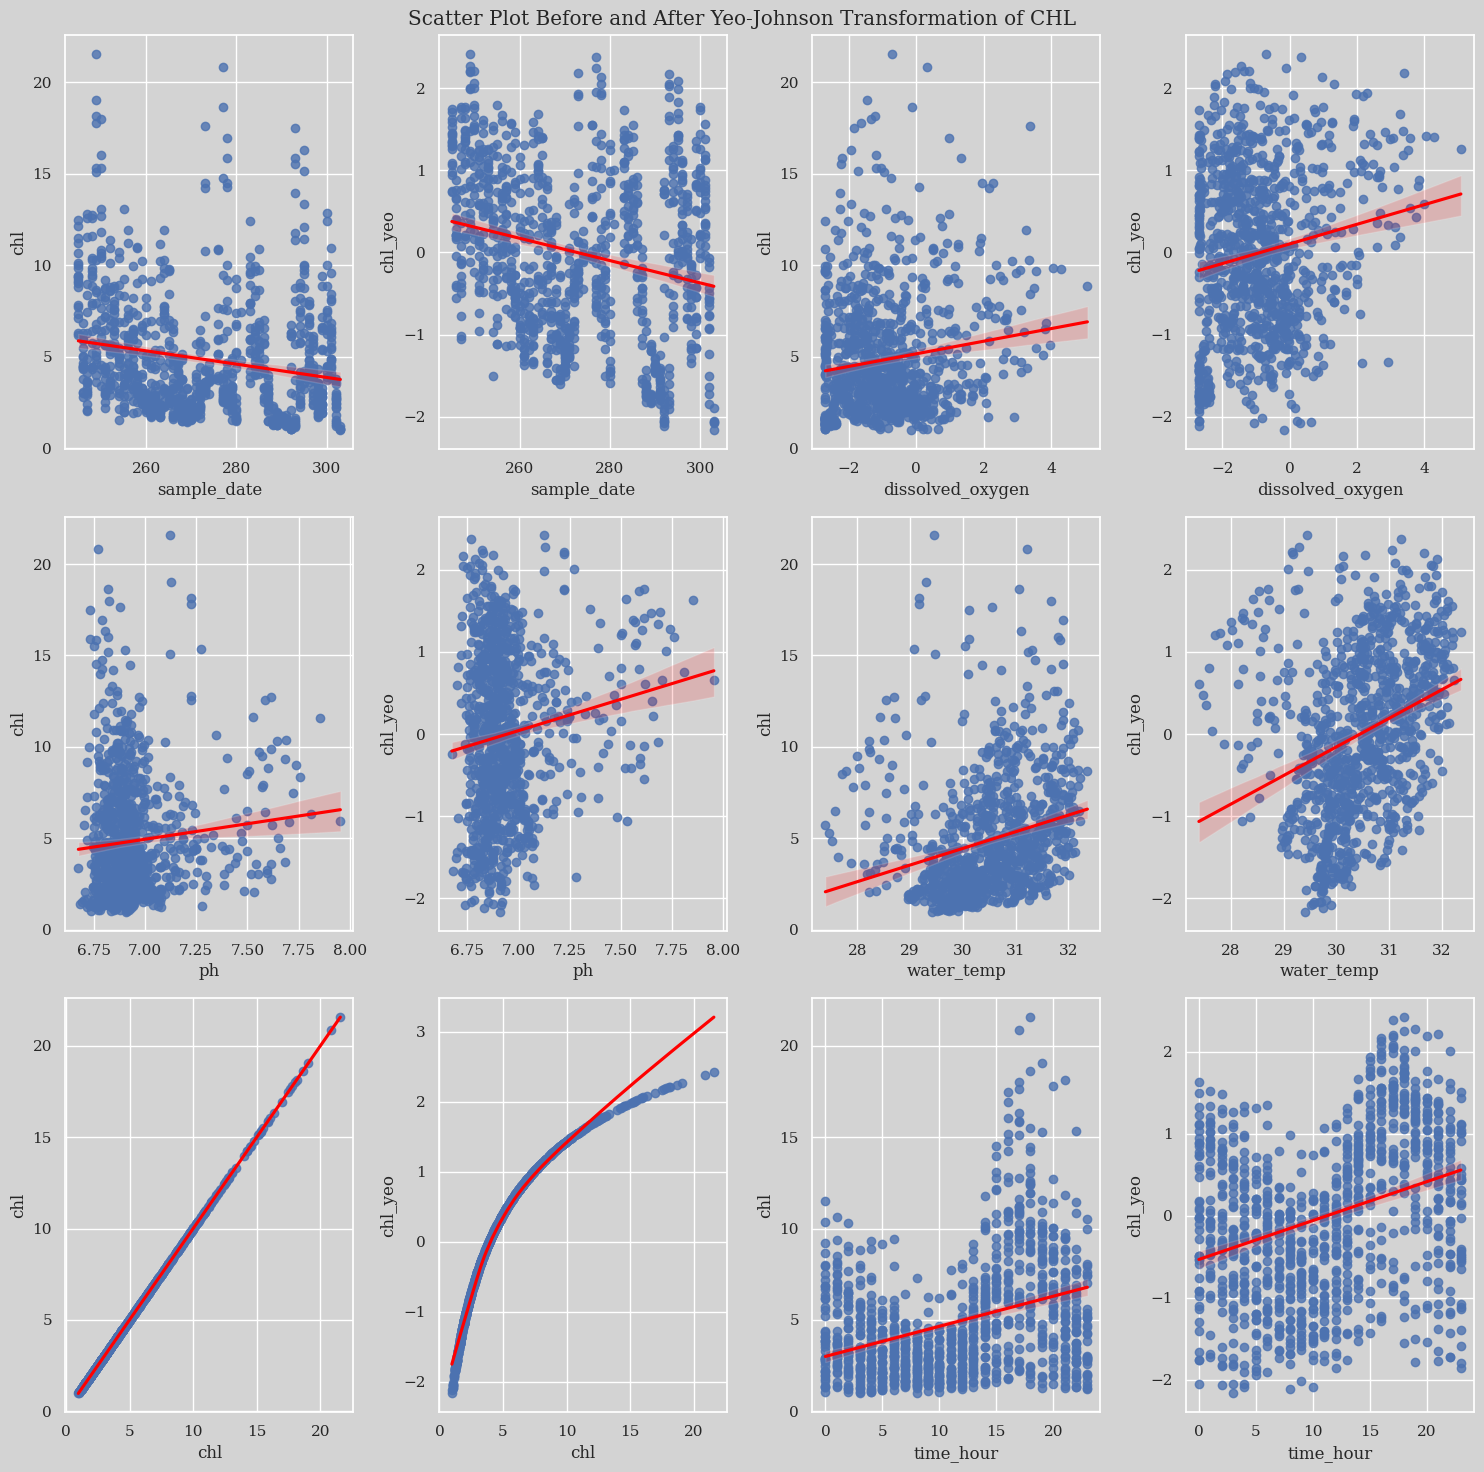

In [59]:
cols = df_filter.drop(columns=["chl_yeo"]).columns.to_list()
rows = int(np.ceil(len(cols)/2))

fig, axes = plt.subplots(ncols=4, nrows=rows, figsize=(15, 5*rows))

axes = axes.flatten()
for i in range(0, len(cols)*2, 2):
    sns.regplot(
        df_filter,
        x=cols[int(i/2)],
        y='chl',
        ax=axes[i],
        line_kws={"color" : "red"}
    )
    

    sns.regplot(
            df_filter,
            x=cols[int(i/2)],
            y='chl_yeo',
            ax=axes[i+1],
            line_kws={"color" : "red"}, 
            lowess=cols[int(i/2)] == "chl"
        )

fig.suptitle("Scatter Plot Before and After Yeo-Johnson Transformation of CHL");

plt.tight_layout()



As we can see, the relationships were exaggerated by the mere fact of transforming the dependent variable and controlling the outliers.

### Dissolved Oxygen

In [60]:
formula = "chl_yeo ~ dissolved_oxygen"
lmlm = ols(formula, data=df_filter)
results = lmlm.fit()
results.rsquared_adj

0.026505352799152004

We can't do log transformation because `dissolved_oxygen` has negative values.

Let's try "Yeo-Jhonson" since it can handle negative values.

In [61]:
from sklearn.preprocessing import PowerTransformer

temp_trans = PowerTransformer()
temp_trans.fit(df_filter[['dissolved_oxygen']])

df_filter['dissolved_oxygen_yeo'] = temp_trans.transform(df_filter[['dissolved_oxygen']])

In [62]:
formula = "chl_yeo ~ dissolved_oxygen_yeo"
lmlm = ols(formula, data=df_filter)
results = lmlm.fit()
results.rsquared_adj

0.018207379882267283

Text(0.5, 1.0, 'Dissolved Oxygen With and Without Yeo-Johnson')

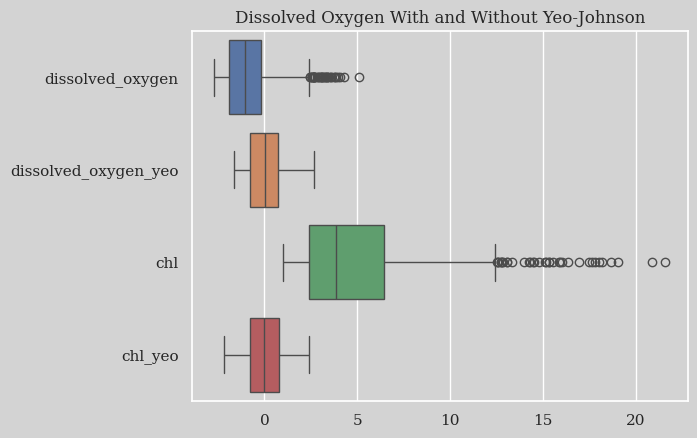

In [63]:
sns.boxplot(
    df_filter[['dissolved_oxygen', 'dissolved_oxygen_yeo', 'chl', 'chl_yeo']],
    orient="h"
)

plt.title("Dissolved Oxygen With and Without Yeo-Johnson")

Although untransformed predictor results to more R-Sq, I think we should still use the transformed version because (1) the outliers was controlled so that will be helpful in the context of multiple linear regression and (2) the difference isn't that much to begin with. 

To be perfectly candid, `dissolved_oxygen` by itself isn't a good predictor in the first place.

### PH

`ph` is a little tricky because the behaviour seem to be significantly different on different intervals. We could use splining in this case. 

In [64]:
formula = "chl_yeo ~ ph"
lmlm = ols(formula, data=df_filter)
results = lmlm.fit()
results.rsquared_adj

0.018544386440687344

This is the best parameter I could get.

In [65]:
formula = "chl_yeo ~ bs(ph, df=5)"
lmlm = ols(formula, data=df_filter)
results = lmlm.fit()
results.rsquared_adj

0.023213365274781128

#### Sample Date

Looking at the scatter plot of `sample_date`, it looks too random to give a significant slope.

In [66]:
formula = "chl_yeo ~ sample_date"
lmlm = ols(formula, data=df_filter)
results = lmlm.fit()
results.rsquared_adj

0.05416579503752206

In [67]:
formula = "chl_yeo ~ sample_date + np.power(sample_date, 2) + np.power(sample_date, 3) +  np.power(sample_date, 4)"
lmlm = ols(formula, data=df_filter)
results = lmlm.fit()
results.rsquared_adj

0.1427609183623021

### Water Tempt

In [68]:
formula = "chl_yeo ~ water_temp"
lmlm = ols(formula, data=df_filter)
results = lmlm.fit()
results.rsquared_adj

0.09776933498198981

In [69]:
temp_trans = PowerTransformer()
temp_trans.fit(df_filter[['water_temp']])

df_filter['water_temp_yeo'] = temp_trans.transform(df_filter[['water_temp']])

In [70]:
formula = "chl_yeo ~ water_temp_yeo"
lmlm = ols(formula, data=df_filter)
results = lmlm.fit()
results.rsquared_adj

0.11379808987981443

In [71]:
formula = "chl_yeo ~ water_temp + np.power(water_temp, 2) + np.power(water_temp, 3) + np.power(water_temp, 4) "
lmlm = ols(formula, data=df_filter)
results = lmlm.fit()
results.rsquared_adj

0.21809220214304315

Yeo-Johnson makes the predictor better but transforming into polynomial regression did best.

### Time Hour

Looking at the scatter plot of `time_hour`, we can fit a polynomial regression as well.

In [72]:
formula = "chl_yeo ~ time_hour"
lmlm = ols(formula, data=df_filter)
results = lmlm.fit()
results.rsquared_adj

0.10549735259863358

In [73]:
formula = "chl_yeo ~ time_hour + np.power(time_hour, 2) + np.power(time_hour, 3) + np.power(time_hour, 4)"
lmlm = ols(formula, data=df_filter)
results = lmlm.fit()
results.rsquared_adj

0.2730358739695863

### Model with Date

In [74]:
formula = "chl_yeo ~ dissolved_oxygen_yeo +  water_temp + np.power(water_temp, 2) + np.power(water_temp, 3) + np.power(water_temp, 4) + time_hour + np.power(time_hour, 2) + np.power(time_hour, 3) + np.power(time_hour, 4) + bs(ph, df=5) + sample_date + np.power(sample_date, 2) + np.power(sample_date, 3) +  np.power(sample_date, 4)"
lmlm = ols(formula, data=df_filter)
results = lmlm.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                chl_yeo   R-squared:                       0.520
Model:                            OLS   Adj. R-squared:                  0.512
Method:                 Least Squares   F-statistic:                     63.59
Date:                Tue, 03 Jun 2025   Prob (F-statistic):          8.05e-146
Time:                        14:05:36   Log-Likelihood:                -1070.1
No. Observations:                1017   AIC:                             2176.
Df Residuals:                     999   BIC:                             2265.
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
============================================================================================
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept                -1708.2103   1.09e+04     -0.157      0.875    -2.3e+04    1.96e+04
dissolved_oxygen_yeo         0.1061      0.030      3.586      0.000       0.048       0.164
water_temp                 481.9676   1452.018      0.332      0.740   -2367.387    3331.322
np.power(water_temp, 2)    -28.8357     72.761     -0.396      0.692    -171.618     113.947
np.power(water_temp, 3)      0.7442      1.619      0.460      0.646      -2.433       3.922
np.power(water_temp, 4)     -0.0070      0.014     -0.522      0.602      -0.034       0.019
time_hour                   -0.0263      0.056     -0.469      0.639      -0.136       0.084
np.power(time_hour, 2)      -0.0301      0.010     -2.879      0.004      -0.051      -0.010
np.power(time_hour, 3)       0.0039      0.001      5.606      0.000       0.003       0.005
np.power(time_hour, 4)      -0.0001   1.49e-05     -7.440      0.000      -0.000   -8.18e-05
bs(ph, df=5)[0]              0.0558      0.461      0.121      0.904      -0.849       0.961
bs(ph, df=5)[1]              0.1476      0.315      0.468      0.640      -0.471       0.766
bs(ph, df=5)[2]              0.8375      0.453      1.847      0.065      -0.052       1.727
bs(ph, df=5)[3]              0.6464      0.643      1.005      0.315      -0.616       1.909
bs(ph, df=5)[4]              0.4369      0.626      0.697      0.486      -0.792       1.666
sample_date                -12.8060      1.610     -7.954      0.000     -15.965      -9.647
np.power(sample_date, 2)     0.0459      0.006      7.831      0.000       0.034       0.057
np.power(sample_date, 3) -5.472e-05    7.1e-06     -7.708      0.000   -6.87e-05   -4.08e-05
np.power(sample_date, 4)  8.341e-11    3.2e-11      2.603      0.009    2.05e-11    1.46e-10
==============================================================================
Omnibus:                        7.016   Durbin-Watson:                   1.879
Prob(Omnibus):                  0.030   Jarque-Bera (JB):                5.380
Skew:                          -0.064   Prob(JB):                       0.0679
Kurtosis:                       2.667   Cond. No.                     5.26e+14
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.26e+14. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

### Model Without Date
Its not ideal to add `sample_date` because we don't have sufficient data for a two full cycle (1 cycle = year). With only 3 months of data, any time trends could be spurious and may likely to result to overfitting.

In [75]:
formula = "chl_yeo ~ dissolved_oxygen_yeo +  water_temp + np.power(water_temp, 2) + np.power(water_temp, 3) + np.power(water_temp, 4) + time_hour + np.power(time_hour, 2) + np.power(time_hour, 3) + np.power(time_hour, 4) + bs(ph, df=5)"
lmlm = ols(formula, data=df_filter)
results = lmlm.fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                chl_yeo   R-squared:                       0.468
Model:                            OLS   Adj. R-squared:                  0.461
Method:                 Least Squares   F-statistic:                     63.07
Date:                Tue, 03 Jun 2025   Prob (F-statistic):          7.84e-127
Time:                        14:05:36   Log-Likelihood:                -1121.7
No. Observations:                1017   AIC:                             2273.
Df Residuals:                    1002   BIC:                             2347.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept               -4459.4449   1.14e+04     -0.391      0.696   -2.68e+04    1.79e+04
dissolved_oxygen_yeo        0.0637      0.024      2.670      0.008       0.017       0.110
water_temp                674.4796   1524.117      0.443      0.658   -2316.347    3665.306
np.power(water_temp, 2)   -37.6537     76.377     -0.493      0.622    -187.530     112.223
np.power(water_temp, 3)     0.9219      1.700      0.542      0.588      -2.414       4.257
np.power(water_temp, 4)    -0.0084      0.014     -0.590      0.555      -0.036       0.019
time_hour                  -0.0465      0.059     -0.790      0.429      -0.162       0.069
np.power(time_hour, 2)     -0.0256      0.011     -2.336      0.020      -0.047      -0.004
np.power(time_hour, 3)      0.0036      0.001      4.959      0.000       0.002       0.005
np.power(time_hour, 4)     -0.0001   1.57e-05     -6.747      0.000      -0.000   -7.49e-05
bs(ph, df=5)[0]             0.1260      0.480      0.262      0.793      -0.816       1.068
bs(ph, df=5)[1]             0.1446      0.327      0.442      0.659      -0.497       0.787
bs(ph, df=5)[2]             1.1637      0.455      2.556      0.011       0.270       2.057
bs(ph, df=5)[3]             2.3766      0.641      3.706      0.000       1.118       3.635
bs(ph, df=5)[4]             1.2594      0.645      1.952      0.051      -0.007       2.525
==============================================================================
Omnibus:                        6.472   Durbin-Watson:                   1.882
Prob(Omnibus):                  0.039   Jarque-Bera (JB):                4.799
Skew:                           0.017   Prob(JB):                       0.0908
Kurtosis:                       2.665   Cond. No.                     4.35e+11
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.35e+11. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

---
## Model Selection

We shall conduct exhaustive search to select the final model.

In [ ]:
from itertools import combinations

potential_predictors = [
    "dissolved_oxygen_yeo",
    "water_temp",
    "np.power(water_temp, 2)",
    "np.power(water_temp, 3)",
    "np.power(water_temp, 4)",
    "time_hour",
    "np.power(time_hour, 2)",
    "np.power(time_hour, 3)",
    "np.power(time_hour, 4)",
    "bs(ph, df=5)[0]",
    "bs(ph, df=5)[1]",
    "bs(ph, df=5)[2]",
    "bs(ph, df=5)[3]",
    "bs(ph, df=5)[4]",
]

results = []

for r in range(1, len(potential_predictors)+ 1):
    comb = combinations(potential_predictors, r)
    for com in comb:
        formula = "chl_yeo ~ " + " + ".join(com)
        model_tempt = ols(formula, data=df_filter)
        model_tempt = model_tempt.fit()

        result = {
            "predictors" : com,
            "r" : r,
            "RSS" : model_tempt.ssr,
            "RSE" : np.sqrt(model_tempt.scale),
            "Adj_RSq" : model_tempt.rsquared_adj,
            "AIC" : model_tempt.aic,
            "BIC" : model_tempt.bic
        }

        results.append(result)

In [ ]:
print("# potential predictors:", len(potential_predictors))

# potential predictors: 14


In [ ]:
exhaustive_search = pd.DataFrame(results)
exhaustive_search.shape

(16383, 7)

In [ ]:
sorted_search = exhaustive_search.sort_values(by="Adj_RSq", ascending=False).reset_index(drop=True).head(20)
sorted_search

,predictors,r,RSS,RSE,Adj_RSq,AIC,BIC
0,"(dissolved_oxygen_yeo, np.power(water_temp, 2)...",10,541.158229,0.733438,0.462598,2266.494979,2320.665715
1,"(dissolved_oxygen_yeo, water_temp, np.power(wa...",10,541.185965,0.733456,0.462571,2266.547103,2320.717839
2,"(dissolved_oxygen_yeo, water_temp, np.power(wa...",10,541.215777,0.733477,0.462541,2266.603125,2320.773861
3,"(dissolved_oxygen_yeo, water_temp, np.power(wa...",10,541.247301,0.733498,0.462510,2266.662359,2320.833095
4,"(dissolved_oxygen_yeo, np.power(water_temp, 2)...",11,540.853760,0.733596,0.462366,2267.922630,2327.017979
5,"(dissolved_oxygen_yeo, water_temp, np.power(wa...",11,540.880241,0.733614,0.462340,2267.972422,2327.067771
6,"(dissolved_oxygen_yeo, water_temp, np.power(wa...",11,540.908855,0.733633,0.462311,2268.026223,2327.121572
7,"(dissolved_oxygen_yeo, water_temp, np.power(wa...",11,540.939245,0.733654,0.462281,2268.083360,2327.178709
8,"(dissolved_oxygen_yeo, water_temp, np.power(wa...",11,541.032770,0.733717,0.462188,2268.259178,2327.354527
9,"(dissolved_oxygen_yeo, np.power(water_temp, 2)...",11,541.099571,0.733763,0.462122,2268.384738,2327.480087


### Best Combinations

In [ ]:
sorted_search.iloc[0, 0]

('dissolved_oxygen_yeo',
 'np.power(water_temp, 2)',
 'np.power(water_temp, 3)',
 'np.power(water_temp, 4)',
 'np.power(time_hour, 2)',
 'np.power(time_hour, 3)',
 'np.power(time_hour, 4)',
 'bs(ph, df=5)[2]',
 'bs(ph, df=5)[3]',
 'bs(ph, df=5)[4]')

In [77]:
def wrangle(data, tranformers={}):
    df_data = data.copy()
    
    cont_vars = df_data.nunique() != 1
    df_data = df_data[df_data.columns[cont_vars]]
    df_data = df_data.rename(columns={"chlorophyll-a": "chl", 
                                            "dissolved oxygen": "dissolved_oxygen",
                                            "water temp": "water_temp"})

    # convert sample date to datetime
    df_data['sample_date'] = pd.to_datetime(df_data["sample_date"])

    # convert time to time_hour
    df_data['time_hour'] = pd.to_datetime(df_data['time'], format="%H:%M:%S").dt.hour
    df_data.drop(columns="time", inplace=True)

    # remove outliers in date
    start = "2022-09-01"
    end = "2022-11-01"
    mask = (df_data['sample_date'] > start) & (df_data['sample_date'] <= end)

    yeos = ['chl', 'dissolved_oxygen']

    df_no_outliers = df_data[mask].copy()

    df_no_outliers['sample_date'] = df_no_outliers['sample_date'].dt.day_of_year
    train_mode = len(tranformers) == 0

    # yeo transformation
    for col in yeos:
        if train_mode:
            print("Train Mode")
            temp_trans = PowerTransformer()
            temp_trans.fit(df_no_outliers[[col]])
            df_no_outliers[f'{col}_yeo'] = temp_trans.transform(df_no_outliers[[col]])
            tranformers[f'{col}_yeo'] = temp_trans
        else:
            print("Test Mode")
            df_no_outliers[f'{col}_yeo'] = tranformers[f'{col}_yeo'].transform(df_no_outliers[[col]])
    

    return df_no_outliers, tranformers

In [89]:
df_train_clean, tranformers = wrangle(df_train)
df_train_clean.head()

Test Mode
Test Mode


,sample_date,dissolved_oxygen,ph,water_temp,chl,time_hour,chl_yeo,dissolved_oxygen_yeo
1352,285,-2.6848,6.9140,30.6774,4.6948,6,0.297475,-1.626052
1190,274,-0.7552,6.8762,30.2540,2.9645,10,-0.448044,0.277789
1116,271,-0.8416,7.0274,28.9762,1.7908,8,-1.264643,0.207301
584,248,-1.4032,7.5692,27.9160,7.8045,22,1.079907,-0.287813
607,249,-1.2160,7.2227,29.1612,18.1379,21,2.214794,-0.115937


In [90]:
df_test_clean, _ = wrangle(df_test, tranformers)
df_test_clean.head()

Test Mode
Test Mode


,sample_date,dissolved_oxygen,ph,water_temp,chl,time_hour,chl_yeo,dissolved_oxygen_yeo
1118,271,-1.1248,6.9518,29.1989,1.7545,10,-1.297041,-0.034622
1653,299,-2.0992,6.8951,30.7062,2.2143,7,-0.924138,-0.981490
941,263,0.8576,6.9014,30.2870,6.9333,23,0.903293,1.272140
1344,284,-2.6944,6.9329,30.9044,9.1355,20,1.308731,-1.637050
1185,274,-0.7600,7.0022,29.6559,3.8357,5,-0.027701,0.273915


---

# Final Model

In [80]:
min_ph = min(df_train_clean['ph'].min(), df_test_clean['ph'].min())
max_ph = max(df_train_clean['ph'].max(), df_test_clean['ph'].max())

# If you only have train data available right now, use its min/max, but be aware
# predictions on test data outside this range will still rely on the boundaries you set here.
# min_ph = df_train_clean['ph'].min() - np.finfo(float).eps
# max_ph = df_train_clean['ph'].max() + np.finfo(float).eps


# Modify the 'cols' tuple to include lower_bound and upper_bound in the bs() call
# Use an f-string to embed the min_ph and max_ph variables
# cols = ('water_temp_yeo',
#         'np.power(time_hour, 2)',
#         'np.power(time_hour, 3)',
#         'np.power(time_hour, 4)',
#         f'bs(ph, df=5, lower_bound={min_ph}, upper_bound={max_ph})')

cols = ('dissolved_oxygen_yeo',
 'np.power(water_temp, 2)',
 'np.power(water_temp, 3)',
 'np.power(water_temp, 4)',
 'np.power(time_hour, 2)',
 'np.power(time_hour, 3)',
 'np.power(time_hour, 4)',
 f'bs(ph, df=5, lower_bound={min_ph}, upper_bound={max_ph})[2]',
 f'bs(ph, df=5, lower_bound={min_ph}, upper_bound={max_ph})[3]',
 f'bs(ph, df=5, lower_bound={min_ph}, upper_bound={max_ph})[4]')

formula = "chl_yeo ~ " + " + ".join(cols)
model = ols(formula, data=df_train_clean)
model = model.fit()
model.summary2()

<class 'statsmodels.iolib.summary2.Summary'>
"""
                                      Results: Ordinary least squares
===========================================================================================================
Model:                             OLS                           Adj. R-squared:                  0.463    
Dependent Variable:                chl_yeo                       AIC:                             2266.4071
Date:                              2025-06-03 14:05              BIC:                             2320.5778
No. Observations:                  1017                          Log-Likelihood:                  -1122.2  
Df Model:                          10                            F-statistic:                     88.47    
Df Residuals:                      1006                          Prob (F-statistic):              1.91e-130
R-squared:                         0.468                         Scale:                           0.53788  
-----------------------------------------------------------------------------------------------------------
                                                         Coef.   Std.Err.    t     P>|t|   [0.025   0.975] 
-----------------------------------------------------------------------------------------------------------
Intercept                                               581.9372 118.5039   4.9107 0.0000 349.3941 814.4804
dissolved_oxygen_yeo                                      0.0662   0.0236   2.8026 0.0052   0.0199   0.1126
np.power(water_temp, 2)                                  -3.8452   0.7801  -4.9289 0.0000  -5.3761  -2.3143
np.power(water_temp, 3)                                   0.1694   0.0344   4.9182 0.0000   0.1018   0.2369
np.power(water_temp, 4)                                  -0.0021   0.0004  -4.8958 0.0000  -0.0029  -0.0013
np.power(time_hour, 2)                                   -0.0340   0.0030 -11.4577 0.0000  -0.0398  -0.0282
np.power(time_hour, 3)                                    0.0041   0.0003  13.3220 0.0000   0.0035   0.0047
np.power(time_hour, 4)                                   -0.0001   0.0000 -13.9674 0.0000  -0.0001  -0.0001
bs(ph, df=5, lower_bound=6.6368, upper_bound=7.9535)[2]   1.0372   0.2139   4.8485 0.0000   0.6174   1.4569
bs(ph, df=5, lower_bound=6.6368, upper_bound=7.9535)[3]   2.3199   0.5136   4.5169 0.0000   1.3120   3.3278
bs(ph, df=5, lower_bound=6.6368, upper_bound=7.9535)[4]   1.1894   0.5154   2.3075 0.0212   0.1779   2.2009
-----------------------------------------------------------------------------------------------------------
Omnibus:                           6.918                    Durbin-Watson:                       1.881     
Prob(Omnibus):                     0.031                    Jarque-Bera (JB):                    5.076     
Skew:                              0.023                    Prob(JB):                            0.079     
Kurtosis:                          2.657                    Condition No.:                       4493456695
===========================================================================================================
Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 4.49e+09. This might indicate                that there are strong
multicollinearity or other numerical                problems.
"""

---
## Assumptions

### Without Significant Outliers

In [ ]:
def detect_outliers(data, mult=1.5, normalized=True):
    '''Count the outliers using iqr'''
    lower, upper = data.quantile([0.25,0.75])

    iqr = upper - lower

    lower_bound, upper_bound = lower - iqr*mult, upper + iqr*mult

    outliers = len(data) - (data.between(lower_bound, upper_bound)).sum()
    if not normalized:
        return outliers
    else:
        return outliers / len(data)

In [ ]:
df_train_clean.drop(columns="sample_date").apply(detect_outliers, axis=0) 

dissolved_oxygen        0.034415
ph                      0.078663
water_temp              0.008850
chl                     0.034415
time_hour               0.000000
chl_yeo                 0.000000
dissolved_oxygen_yeo    0.000000
dtype: float64

`ph` is the only one left with outliers (we didn't use `chl` and `dissolved_oxygen`). 

### No Multi Collinearity

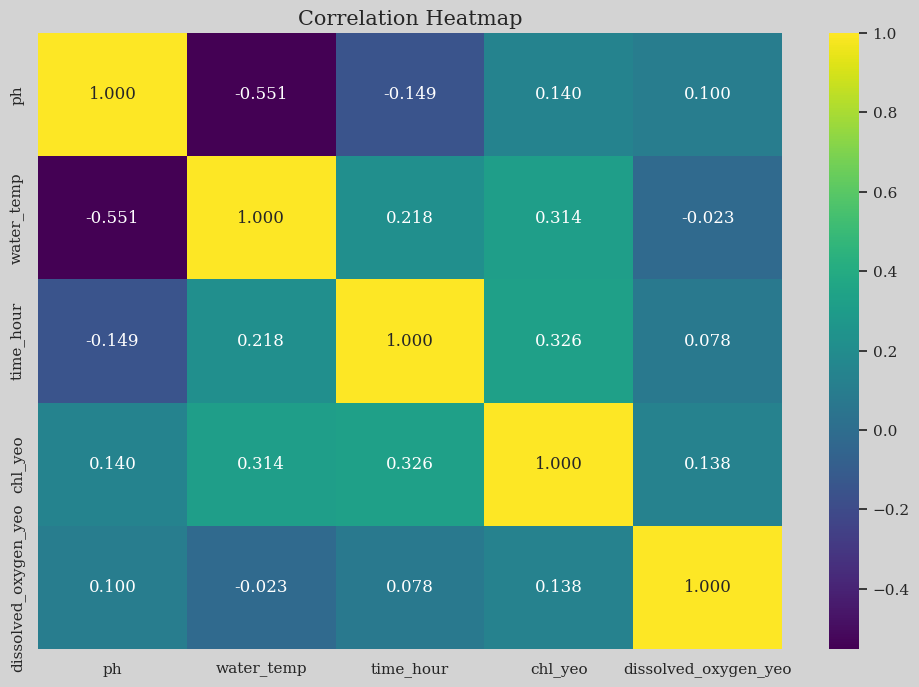

In [ ]:
corr = df_train_clean.drop(columns=['chl', 'dissolved_oxygen', 'sample_date']).corr()
plt.figure(figsize=(12,8))
sns.heatmap(
    corr,
    annot=True,
    fmt=".3f",
    cmap='viridis'
)

plt.title("Correlation Heatmap", size=15);

### Linear Relationship between Predictors and Response

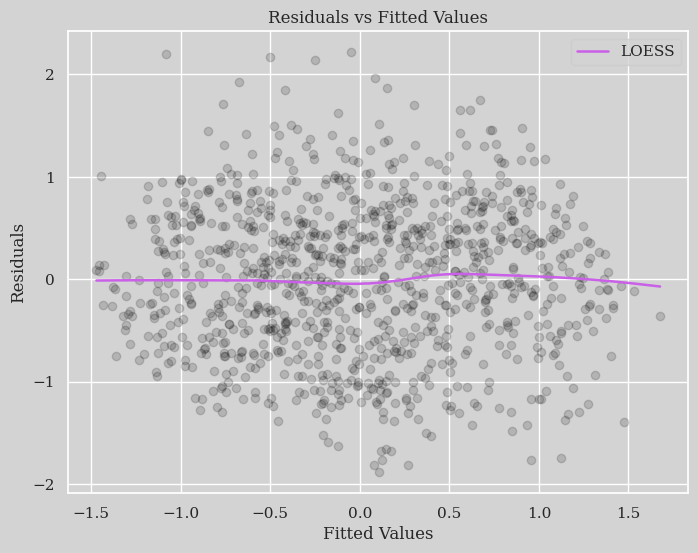

In [ ]:
plt.figure(figsize=(8, 6))

sns.regplot(x=model.predict(), 
            y=model.resid, 
            scatter_kws={'alpha':0.15, 'color' : "black"}, 
            line_kws={'color': '#ca5fe8', "label" : "LOESS", "linewidth" : 1.8},
            lowess=True,
            ci=False)

plt.title('Residuals vs Fitted Values')
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.legend()

plt.show()

Since the LOESS curve is relatively horizontal with residuals hovering aroud 0 and the line, we can say that the assumption of linearity was met.

### Residuals are Normally Distributed

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(model.resid.to_frame())
standardized_resid = scaler.transform(model.resid.to_frame()).squeeze()
standardized_resid_sorted = np.sort(standardized_resid)

normal_theo = np.sort(np.random.normal(0, 1, len(standardized_resid)));

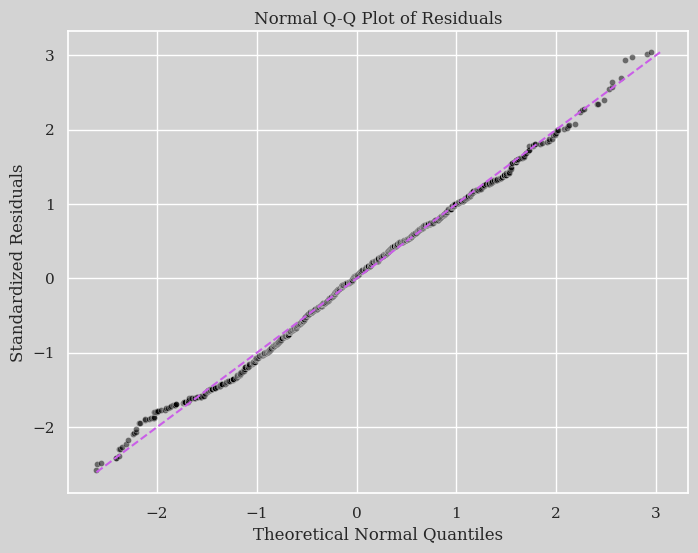

In [ ]:

fig, ax = plt.subplots(ncols=1, figsize=(8, 6))


sns.scatterplot(x=normal_theo,
                y=standardized_resid_sorted,
                color="black",
                ax=ax,
                alpha=0.5,
                s=20)

line_coords = np.linspace(min(normal_theo), max(standardized_resid_sorted))

ax.plot(line_coords, line_coords, color='#ca5fe8', linestyle="--") 


ax.set_title('Normal Q-Q Plot of Residuals')
ax.set_xlabel('Theoretical Normal Quantiles')
ax.set_ylabel('Standardized Residuals');


### Homoscedasticity (Equality in Variance)

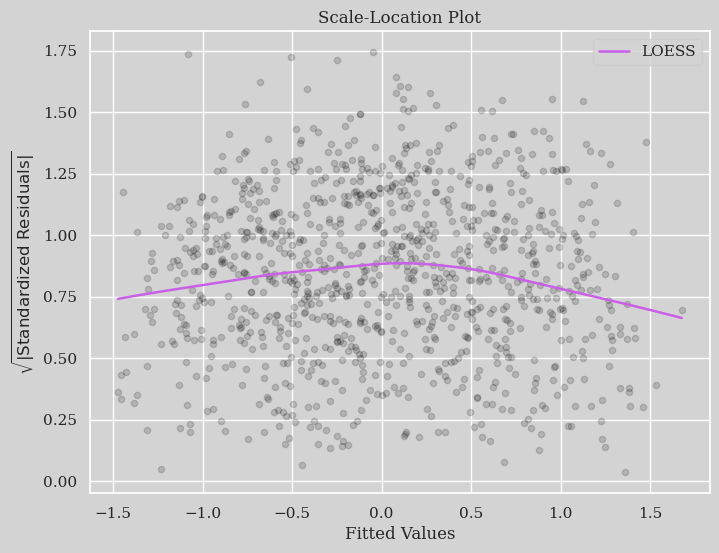

In [ ]:
abs_standardized_resid = np.abs(standardized_resid)
sqrt_abs_standardized_resid = np.sqrt(abs_standardized_resid)

fig, ax = plt.subplots(ncols=1, figsize=(8, 6))
sns.regplot(x=model.predict(),
            y=sqrt_abs_standardized_resid,
            ax=ax,
            scatter_kws={'alpha': 0.15, 'color': 'black', 's': 20}, 
            line_kws={'color': '#ca5fe8', "label" : "LOESS", "linewidth" : 1.8},
            lowess=True,
            ci=False    
           )

ax.set_title('Scale-Location Plot')
ax.set_xlabel('Fitted Values') 
ax.set_ylabel(r'$\sqrt{|\text{Standardized Residuals}|}$')

plt.legend()
plt.show()


The $\sqrt{|\text{standardised residuals}|}$ scatter stays fairly even across fitted values; the LOESS curve is flat until the far right where it drifts downward. No classic “megaphone” shape appears—so constant error variance is acceptable.

### Indendependence of Observed Values

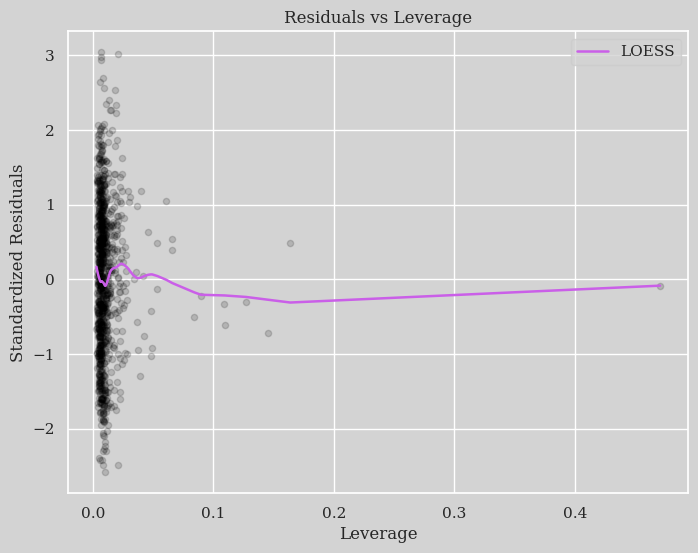

In [ ]:
influence = model.get_influence()
leverage_values = influence.hat_matrix_diag

scaler = StandardScaler()
scaler.fit(model.resid.to_frame())
standardized_resid = scaler.transform(model.resid.to_frame()).squeeze()

fig, ax = plt.subplots(ncols=1, figsize=(8, 6))
sns.regplot(x=leverage_values,
            y=standardized_resid,
            ax=ax,
            scatter_kws={'alpha': 0.15, 'color': 'black', 's': 20}, 
            line_kws={'color': '#ca5fe8', "label" : "LOESS", "linewidth" : 1.8},
            lowess=True,
            ci=False    
           )

ax.set_title('Residuals vs Leverage')
ax.set_ylabel('Standardized Residuals') 
ax.set_xlabel('Leverage')

plt.legend()
plt.show()

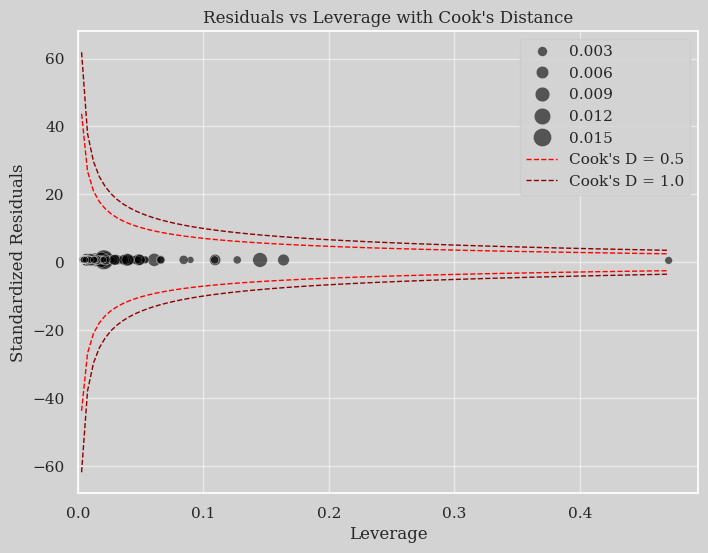

In [ ]:
influence = model.get_influence()

standardized_resid = influence.resid_std
leverage_values = influence.hat_matrix_diag
cooks_distance = influence.cooks_distance[0] 


fig, ax = plt.subplots(ncols=1, figsize=(8, 6))

sns.scatterplot(x=leverage_values,
                y=standardized_resid,
                size=cooks_distance,
                sizes=(20, 200),
                alpha=0.6,
                color='black',
                legend="brief", 
                ax=ax)


num_params = model.df_model + 1

leverage_plot = np.linspace(leverage_values.min(), leverage_values.max(), 100)
leverage_plot = leverage_plot[(leverage_plot > 0) & (leverage_plot < 1)]

def cooks_threshold_y(cooks_d, leverage, num_params):
    h_ii_safe = leverage + np.finfo(float).eps # to avoid division by 0

    one_minus_h_ii_safe = (1 - leverage) + np.finfo(float).eps
    
    numerator = cooks_d * num_params * one_minus_h_ii_safe
    denominator = h_ii_safe
    
    y_squared = np.divide(numerator, denominator, out=np.full_like(numerator, np.nan), where=denominator!=0)
    y_squared[y_squared < 0] = 0 

    return np.sqrt(y_squared)

cooks_d_threshold1 = 0.5
cooks_d_threshold2 = 1.0

y_threshold1 = cooks_threshold_y(cooks_d_threshold1, leverage_plot, num_params)
y_threshold2 = cooks_threshold_y(cooks_d_threshold2, leverage_plot, num_params)

ax.plot(leverage_plot, y_threshold1, label=f"Cook's D = {cooks_d_threshold1}", color='red', linestyle='--', lw=1)
ax.plot(leverage_plot, -y_threshold1, color='red', linestyle='--', lw=1)
ax.plot(leverage_plot, y_threshold2, label=f"Cook's D = {cooks_d_threshold2}", color='darkred', linestyle='--', lw=1)
ax.plot(leverage_plot, -y_threshold2, color='darkred', linestyle='--', lw=1) 


ax.set_title("Residuals vs Leverage with Cook's Distance") 
ax.set_ylabel('Standardized Residuals')
ax.set_xlabel('Leverage')
ax.set_xlim(left=0)

ax.legend()

plt.grid(True, linestyle='-', alpha=0.5)
plt.show()

Reference for cooks distance threshold: https://bookdown.org/colettemair0/bookdown/cooks-distance-and-leverage.html

**Cook's Distance contours** 

$r_i = \pm \sqrt{C \cdot p \cdot \frac{1 - h_{ii}}{h_{ii}}}$

Where: 
* $D_i$ - Cook's Distance 
* $r_i$ - studentized residual
* $h_{ii}$ - leverage value
* $p$ - number of parameters including intercept

All bubbles fall well inside the innermost red contour (D ≈ 0.5). No observation simultaneously shows large residual and high leverage, so the model is robust against influential outliers. No deletion diagnostics are triggered.

---

## Evaluation

In [82]:
def mae(y_true, y_pred):
    error = y_true - y_pred
    return abs(error).sum() / len(y_true)

In [87]:
# inversing yeo transformation to original scale
def revert_yeo(y : np.array, unscaled_colname : str, scaled_colname, transformers : dict):
    y_frame = y.to_frame().rename({0: scaled_colname}, axis=1)
    y_scaled_copy = y_frame.copy().rename({scaled_colname : unscaled_colname}, axis=1)
    return transformers[scaled_colname].inverse_transform(y_scaled_copy).squeeze()

In [92]:
# Get scaled targets
y_train = df_train_clean['chl_yeo']
y_test = df_test_clean['chl_yeo']

# Get unscaled targets for proper comparison
y_train_unscaled = df_train_clean['chl']  # assuming you have this column
y_test_unscaled = df_test_clean['chl']    # assuming you have this column

# Mean model MAE (scaled)
mae_train_mean = mae(y_train, y_train.mean())
mae_test_mean = mae(y_test, y_train.mean())

# Baseline model MAE (scaled)
y_pred_train_base = results_baseline.predict(df_train_clean)
mae_train_base = mae(y_train, y_pred_train_base)
y_pred_test_base = results_baseline.predict(df_test_clean)
mae_test_base = mae(y_test, y_pred_test_base)

# Final model MAE (scaled)
y_pred_train_final = model.predict(df_train_clean)
mae_train_final = mae(y_train, y_pred_train_final)
y_pred_test_final = model.predict(df_test_clean)
mae_test_final = mae(y_test, y_pred_test_final)

# Convert predictions back to original scale
scaled_colname = "chl_yeo"
unscaled_colname = 'chl'

y_pred_train_unscaled = revert_yeo(y_pred_train_final, unscaled_colname, scaled_colname, tranformers)
y_pred_test_unscaled = revert_yeo(y_pred_test_final, unscaled_colname, scaled_colname, tranformers)

# Calculate MAE on original scale (comparing unscaled targets with unscaled predictions)
mae_train_final_unscaled = mae(y_train_unscaled, y_pred_train_unscaled)
mae_test_final_unscaled = mae(y_test_unscaled, y_pred_test_unscaled)

results = {
    "baseline model (raw)" : {"train set": mae_train_base, "test set" : mae_test_base},
    "final model (raw)" : {"train set" : mae_train_final_unscaled, "test set" : mae_test_final_unscaled},
    "final model (yeo scaled)" : {"train set" : mae_train_final, "test set" : mae_test_final},
    "mean model (yeo scaled)" : {"train set": mae_train_mean, "test set" : mae_test_mean},
}

pd.DataFrame(results)

,baseline model (raw),final model (raw),final model (yeo scaled),mean model (yeo scaled)
train set,4.853528,1.784857,0.597998,0.838578
test set,4.780070,1.822802,0.611833,0.830518


The model has performed significantly well above the baseline model and the mean model across all sets. The scoring method used was Mean Absolute Error instead of the traditional Mean Squared Error to intuitively compare the different scales. The training and test score of `final model (yeo scaled)` do not fall far away from each other. This simply means that the model performed similarly between the data it has seen and the data it has not. So the final model could be generalize.  Also, by applying inverse transformation to the prediction of the model, a comparison can be made in the original scale. For reference, the standard deviation of the untransformed response is 4.7393 (0.9837 on transformed). Taking that into consideration, an MAE  of 1.822802 in original scale of final model is a great score since the model was able to predict chlorophyll-a concentrations with an average error substantially smaller than their inherent natural variability, demonstrating a meaningful reduction in uncertainty.

---
## Communication

In [ ]:
list_params = model.params[1:].index.to_list()
results = []
r_sq = model.rsquared_adj

for param in list_params:
    temp_params = model.params[1:].index.to_list()
    temp_params.remove(param)
    
    formula = "chl_yeo ~ " + " + ".join(temp_params)

    model_tempt = ols(formula, data=df_train_clean)
    model_tempt = model_tempt.fit()

    string_to_remove = ", lower_bound=6.1706, upper_bound=8.0606"
    result_replace = param.replace(string_to_remove, "")

    result = {
            "predictor_wo" : result_replace,
            "RSS" : model_tempt.ssr,
            "RSE" : np.sqrt(model_tempt.scale),
            "Adj_RSq" : model_tempt.rsquared_adj,
            "difference_adj_rsq" : r_sq - model_tempt.rsquared_adj,
            "AIC" : model_tempt.aic,
            "BIC" : model_tempt.bic
        }
    
    results.append(result)

In [ ]:
df_com_importance = pd.DataFrame(results)
df_com_importance

,predictor_wo,RSS,RSE,Adj_RSq,difference_adj_rsq,AIC,BIC
0,dissolved_oxygen_yeo,545.336363,0.735898,0.458987,0.003658,2272.316802,2321.562926
1,"np.power(water_temp, 2)",554.178633,0.741840,0.450215,0.012430,2288.674527,2337.920651
2,"np.power(water_temp, 3)",554.122097,0.741802,0.450271,0.012374,2288.570769,2337.816893
3,"np.power(water_temp, 4)",554.003983,0.741723,0.450388,0.012257,2288.353968,2337.600092
4,"np.power(time_hour, 2)",611.723954,0.779405,0.393126,0.069519,2389.148074,2438.394198
5,"np.power(time_hour, 3)",636.573305,0.795078,0.368473,0.094171,2429.643444,2478.889567
6,"np.power(time_hour, 4)",646.046025,0.800971,0.359076,0.103569,2444.665719,2493.911843
7,"bs(ph, df=5, lower_bound=6.6368, upper_bound=7...",553.755985,0.741557,0.450634,0.012011,2287.898610,2337.144734
8,"bs(ph, df=5, lower_bound=6.6368, upper_bound=7...",552.085583,0.740438,0.452291,0.010353,2284.826198,2334.072322
9,"bs(ph, df=5, lower_bound=6.6368, upper_bound=7...",543.975577,0.734979,0.460337,0.002308,2269.775894,2319.022018


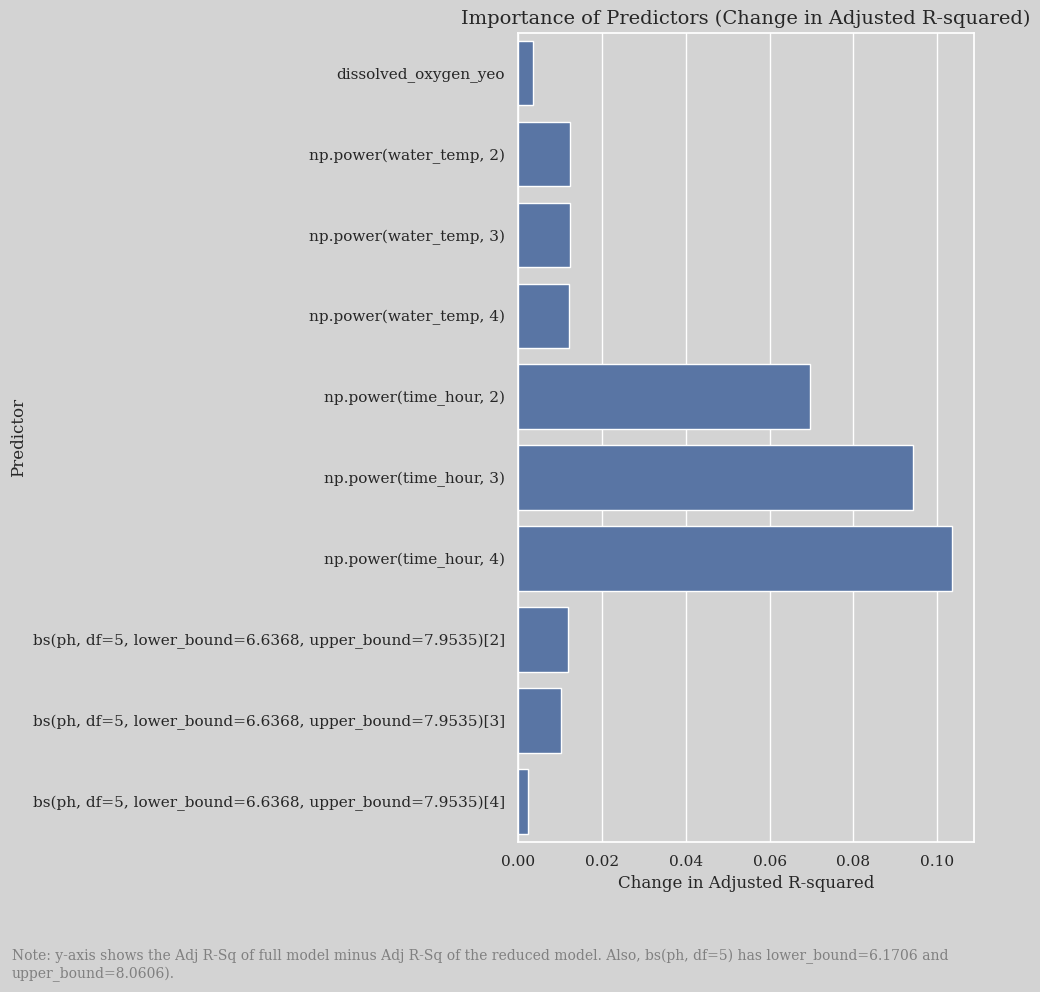

In [ ]:
fig, ax = plt.subplots(figsize=(10, 10))

sns.barplot(
    x=df_com_importance.difference_adj_rsq,
    y=df_com_importance.predictor_wo,
    ax=ax # Pass the axes object here
)

ax.set_xlabel('Change in Adjusted R-squared')
ax.set_ylabel('Predictor')
ax.set_title('Importance of Predictors (Change in Adjusted R-squared)', size=14)

note_text = "Note: y-axis shows the Adj R-Sq of full model minus Adj R-Sq of the reduced model. Also, bs(ph, df=5) has lower_bound=6.1706 and upper_bound=8.0606)."

fig.text(
    0.02,     
    0.01,       
    note_text, 
    wrap=True,  
    horizontalalignment='left',
    verticalalignment='bottom', 
    fontsize=10,
    color='gray' 
)

plt.tight_layout() 

plt.subplots_adjust(bottom=0.15)

plt.show()

The above figure is a graph showing the importance of each parameter in the final model. The most significant predictor by far is the ‘time_hour’ transformed with polynomials.  This means that the time that the sample was taken is the most important (at least among the predictors) in predicting chlorophyll-a concentrations.  The second most important predictor is the ‘water_temp’ or the water temperature. Followed by the ‘dissolved_oxygen_yeo’ or the transformed ‘dissolved_oxygen’ column. This in particular is a significant improvement from the relationship on untransformed ‘chl’ (see the baseline model). This significant improvement is a perfect exhibition of the importance of finding the right transformation.  The ‘ph,’ on the other hand remained insignificant which may be indicative of it’s predictive limitation towards chlorophyll-a concentrations.